# 02 · Sentiment: baseline vs pretrained vs fine-tuned transformer
**Task:** positive (4-5★) vs negative (1-2★); 3★ excluded (ambiguous). **Split by product** (70/10/20) so the test set contains only products no model has seen.
All three models are compared on the *same* 8,000-review test subset.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
from IPython.display import Image
from reviewintel import config as C
m = json.loads((C.ARTIFACTS_DIR / "sentiment_metrics.json").read_text())
print(m["data"])
rows = []
for k, lab in (("tfidf_logreg", "TF-IDF + LR (78k train)"), ("pretrained_distilbert_sst2", "DistilBERT SST-2 zero-shot"), ("finetuned_distilbert", "DistilBERT fine-tuned (6.4k)")):
    x = m[k]["subset_test"]
    rows.append({"model": lab, "accuracy": x["accuracy"], "macro_f1": x["macro_f1"], "roc_auc": x["roc_auc"], "neg_precision": x["negative"]["precision"], "neg_recall": x["negative"]["recall"], "neg_f1": x["negative"]["f1"], "brier": x["brier"]})
pd.DataFrame(rows).round(3)

{'labelled': 111408, 'train': 77869, 'valid': 11210, 'test': 22329, 'subset_test': 8000, 'positive_share_pct': 82.11439034898751, 'runtime_min': 42.862617790699005}


,model,accuracy,macro_f1,roc_auc,neg_precision,neg_recall,neg_f1,brier
0,TF-IDF + LR (78k train),0.953,0.919,0.988,0.812,0.930,0.867,0.036
1,DistilBERT SST-2 zero-shot,0.819,0.758,0.954,0.477,0.952,0.636,0.163
2,DistilBERT fine-tuned (6.4k),0.936,0.896,0.986,0.739,0.952,0.832,0.051


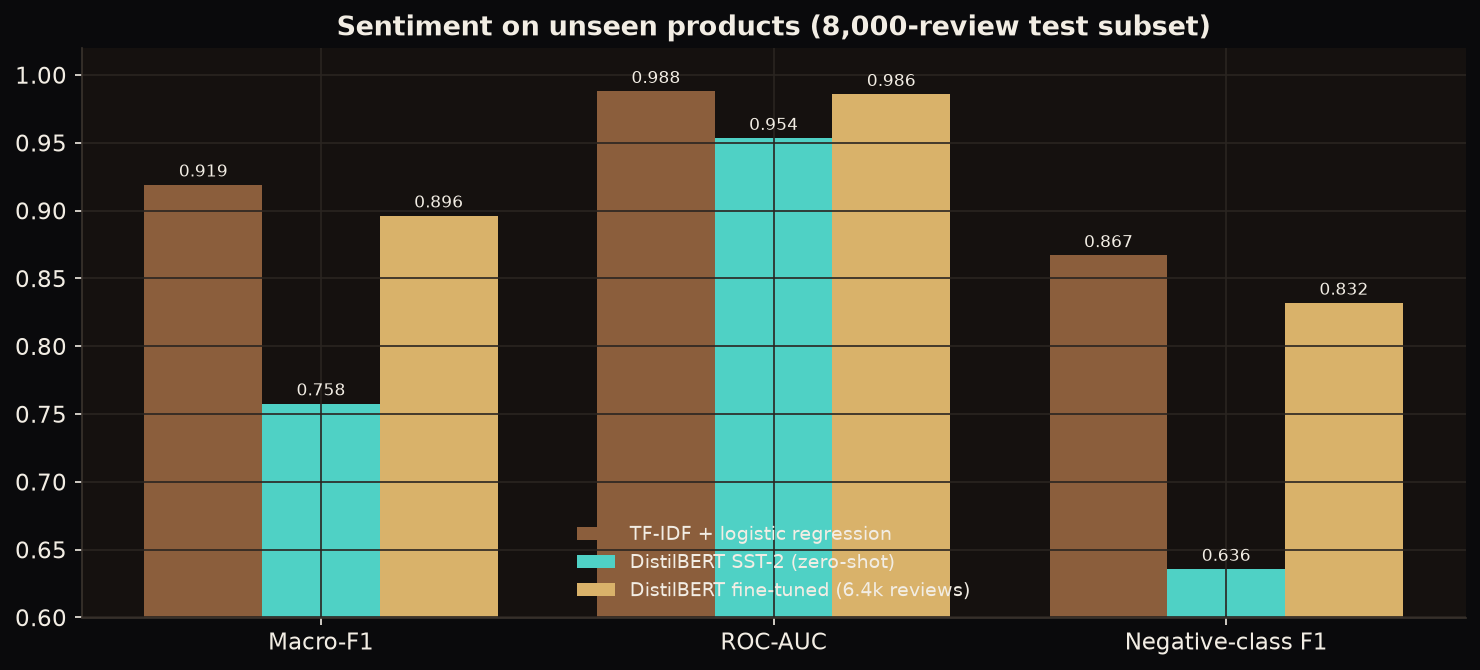

In [2]:
Image(str(C.FIGURES_DIR / "03_sentiment_models.png"))

**Reading it honestly**
* The zero-shot movie-review model is a poor fit for product reviews (macro-F1 0.758; it flags many mild-praise reviews as negative: negative precision 0.48).
* **The simple TF-IDF + logistic regression is the strongest at the default threshold** (macro-F1 0.919, AUC 0.988) - but it saw 78k labelled reviews; the transformer saw only 6.4k (one CPU epoch, ~25 min).

### Fair comparison at equal training data, and threshold effects

In [3]:
lc = pd.DataFrame(m["lr_learning_curve"]).T[["n_train", "accuracy", "macro_f1", "roc_auc"]].round(4)
lc.loc["DistilBERT fine-tuned (same 6.4k reviews)"] = [6400, m["finetuned_distilbert"]["subset_test"]["accuracy"], m["finetuned_distilbert"]["subset_test"]["macro_f1"], m["finetuned_distilbert"]["subset_test"]["roc_auc"]]
lc.round(4)

,n_train,accuracy,macro_f1,roc_auc
same_6400_balanced_as_transformer,6400,0.91875,0.871779,0.979478
random_20000,20000,0.944,0.904105,0.982601
all_train,77869,0.95275,0.919178,0.988086
DistilBERT fine-tuned (same 6.4k reviews),6400.0,0.93625,0.896338,0.985906


In [4]:
thr = pd.DataFrame({k: {"threshold": m[k]["subset_test_tuned_threshold"]["threshold"], "macro_f1": m[k]["subset_test_tuned_threshold"]["macro_f1"], "neg_f1": m[k]["subset_test_tuned_threshold"]["negative"]["f1"], "accuracy": m[k]["subset_test_tuned_threshold"]["accuracy"]}
                    for k in ("pretrained_distilbert_sst2", "finetuned_distilbert")}).T.round(3)
print("Decision threshold chosen on a validation subset (maximising macro-F1):"); thr

Decision threshold chosen on a validation subset (maximising macro-F1):


,threshold,macro_f1,neg_f1,accuracy
pretrained_distilbert_sst2,0.05,0.799,0.687,0.861
finetuned_distilbert,0.06,0.920,0.868,0.956


* **At equal data the fine-tuned transformer wins:** LR trained on the same 6,400 reviews scores macro-F1 0.872 (AUC 0.980) vs 0.896 (AUC 0.986) for DistilBERT. Data efficiency is the transformer's real advantage.
* **Prior shift:** fine-tuning on a balanced sample (50% negative) makes the model over-predict negatives on the natural 82/18 population; a validation-chosen threshold of 0.06 lifts macro-F1 from 0.896 to **0.920**, on par with the LR trained on ten times more data.
* **Decision:** the deployed app uses the LR (tiny, thousands of reviews/second, needs no GPU/torch, best calibrated: Brier 0.036 vs 0.051). The fine-tuned DistilBERT is an optional second opinion (~19 reviews/s on CPU zero-shot speed).

### Where do models fail?

In [5]:
print("macro-F1 by category:", {k: {a: round(b, 3) for a, b in v.items() if a != 'n'} for k, v in m["by_category"].items()})
print("macro-F1 by review length:", {k: {a: round(b, 3) for a, b in v.items() if a != 'n'} for k, v in m["by_length"].items()})
print("accuracy by star rating (correct side of 3):", {k: {a: round(b, 3) for a, b in v.items()} for k, v in m["by_rating"].items()})

macro-F1 by category: {'All_Beauty': {'lr': 0.928, 'pretrained': 0.849, 'finetuned': 0.917}, 'Appliances': {'lr': 0.905, 'pretrained': 0.667, 'finetuned': 0.867}}
macro-F1 by review length: {'<80': {'lr': 0.942, 'pretrained': 0.803, 'finetuned': 0.915}, '80-200': {'lr': 0.918, 'pretrained': 0.766, 'finetuned': 0.905}, '200-500': {'lr': 0.915, 'pretrained': 0.74, 'finetuned': 0.895}, '>500': {'lr': 0.858, 'pretrained': 0.61, 'finetuned': 0.805}}
accuracy by star rating (correct side of 3): {'1': {'lr': 0.959, 'pretrained': 0.969, 'finetuned': 0.975}, '2': {'lr': 0.869, 'pretrained': 0.916, 'finetuned': 0.904}, '4': {'lr': 0.872, 'pretrained': 0.608, 'finetuned': 0.808}, '5': {'lr': 0.972, 'pretrained': 0.824, 'finetuned': 0.954}}


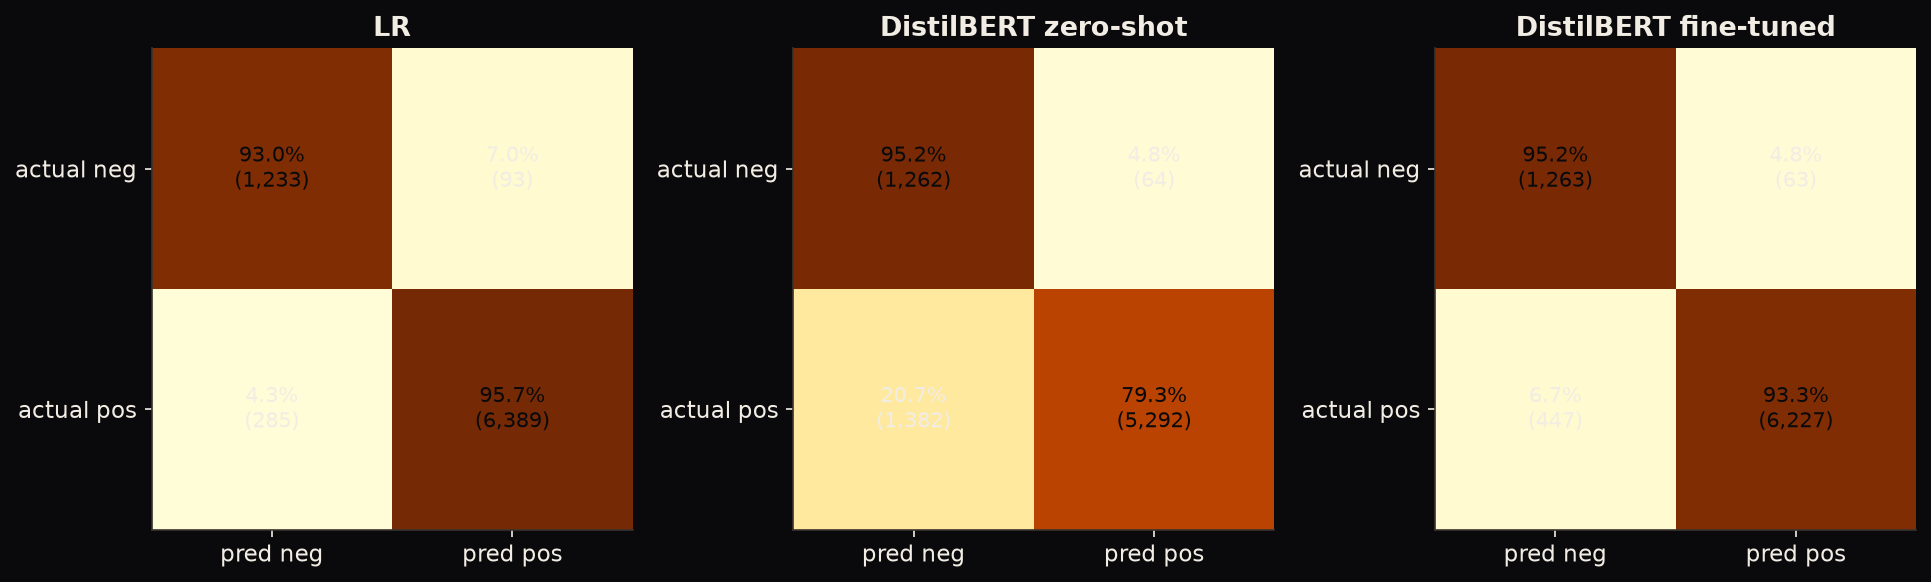

In [6]:
Image(str(C.FIGURES_DIR / "04_confusion.png"))

In [7]:
d = pd.read_parquet(C.PROCESSED_DIR / "sentiment_test_predictions.parquet")
d["lr_pred"] = (d.p_lr >= 0.5).astype(int); d["ft_pred"] = (d.p_finetuned >= m["thresholds"]["finetuned"]).astype(int)
both = d[(d.lr_pred != d.label) & (d.ft_pred != d.label)]
print(f"{len(both)} reviews are misclassified by BOTH models; LR only: {((d.lr_pred != d.label) & (d.ft_pred == d.label)).sum()}, fine-tuned only: {((d.lr_pred == d.label) & (d.ft_pred != d.label)).sum()}")
pd.set_option("display.max_colwidth", 200)
both.sample(6, random_state=2)[["rating", "title", "text"]].assign(text=lambda x: x.text.str.slice(0, 200))

137 reviews are misclassified by BOTH models; LR only: 241, fine-tuned only: 219


,rating,title,text
5914,5.0,Replace those expensive Nespresso Pods,"I love my Nespresso Vertuo machine, but the aluminum pods are wasteful and expensive. I’ve never been able to get a decent aftermarket product to work in it. Now I can reuse their pods and put my ..."
6100,1.0,The feel of the soap is great. It rinses clean,"I got this because I read the reviews, and this is the first negative I have ever given a product. I got the soap and the only thing the scent reminds me of is dog food. The feel of the soap is gr..."
3557,2.0,"Pretty, but impractical","My sister has 3a hair and I have 3c. Our hair slipped out of these dreads constantly. I've always done goddess locs and wanted to dry something different. The color is beautiful, but the hair neve..."
377,4.0,Meh.,"It smells great, but doesn't work as well as dove for women, in my opinion."
2775,4.0,"Was not as shown, the compartments on the door ...","Was not as shown, the compartments on the door are not as shown in the picture. The unit is much smaller than I expected. but then I didn't look at the dimensions that close."
219,1.0,Gift,Given as gift. Recipient was thrilled. Do not want to personally review a product I am not using. The service was expedient and I am pleased with that.


**Error analysis**
* Errors concentrate on the *borderline stars*: LR error rate is 13% for 2★ and 13% for 4★ vs 4% for 1★ and 3% for 5★. These are mixed reviews ("works well but the rose fragrance is too strong").
* Shared errors also include **label noise**: a 1★ review titled "Gentle effective facial cleanser", and 2★ reviews whose text is mildly positive ("Cartridge fits and works properly, but water tastes different").
* Long reviews (> 500 characters) are the hardest (macro-F1 0.86 for LR): the verdict is buried in a narrative, and the transformer is truncated at 96-128 tokens.
* Appliances is harder than Beauty for every model (LR 0.905 vs 0.928).

### Robustness
LR trained on reviews from ≤ 2020 and tested on 2021+ (any product) keeps macro-F1 at 0.918, so there is no visible temporal decay in this sample.